In [34]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline 
import plotly.graph_objs as go
import plotly.figure_factory as ff
import seaborn as sns
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
import lightgbm as lgb

## EDA (Breve)

In [35]:
# Conhecendo a base
df = pd.read_csv('../data/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [37]:
# A variável target apresenta forte desbalanceamento, típico de problemas de detecção de fraude
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [38]:
# A base não possui valores nulos para nenhuma variável
df.isna().sum().tail()

V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

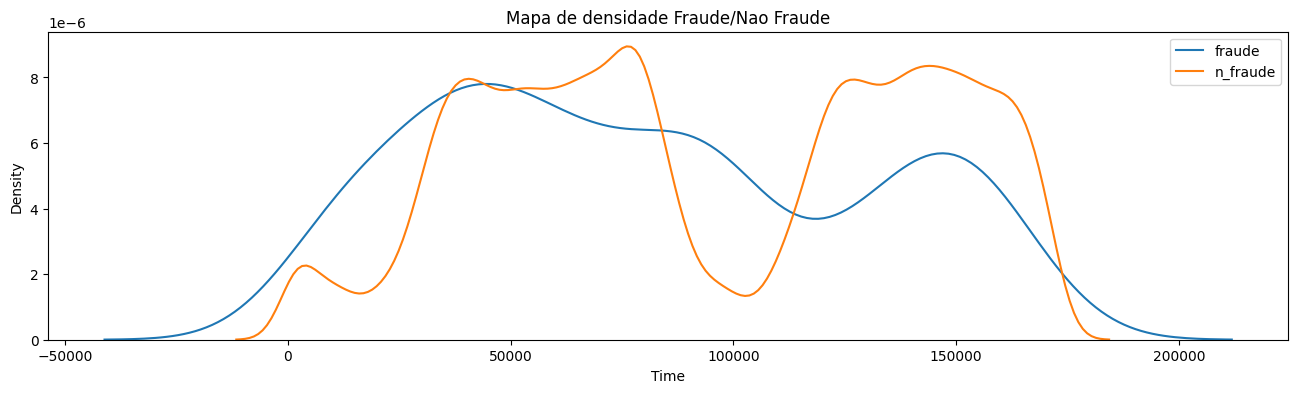

In [39]:
# Analisando quando as fraudes ocorreram?
df_tempo_n_fraude = df.loc[df['Class'] == 0]['Time']
df_tempo_fraude = df.loc[df['Class'] == 1]['Time']

fig, ax = plt.subplots(figsize=(16, 4))

sns.kdeplot(df_tempo_fraude, label='fraude')
sns.kdeplot(df_tempo_n_fraude, label='n_fraude')

ax.set_title('Mapa de densidade Fraude/Nao Fraude')
ax.legend()
plt.show()



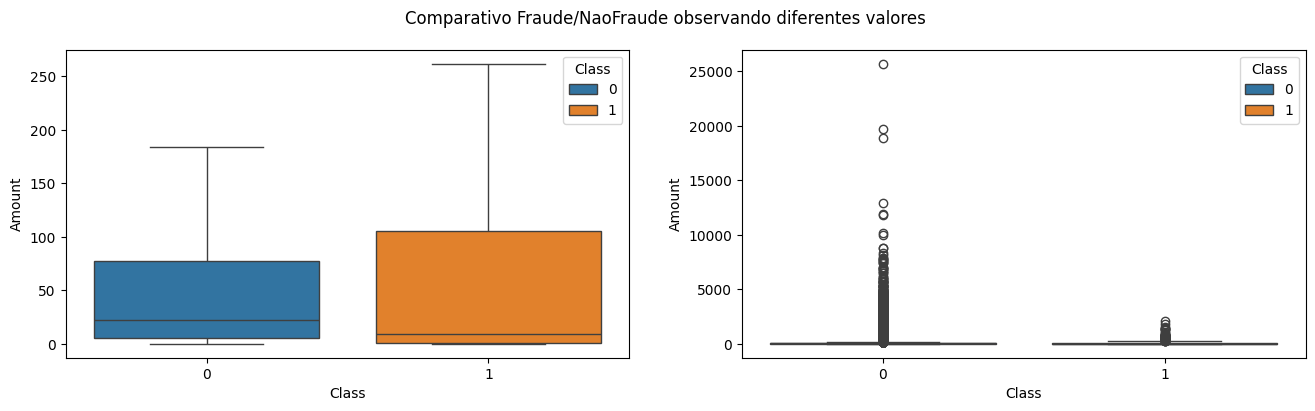

In [40]:
# Valor das transacoes
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(16,4))
fig.suptitle('Comparativo Fraude/NaoFraude observando diferentes valores')
sns.boxplot(ax=ax1, x='Class', y='Amount', hue='Class', data=df, showfliers=False)
sns.boxplot(ax=ax2, x='Class', y='Amount', hue='Class', data=df, showfliers=True)
plt.show()

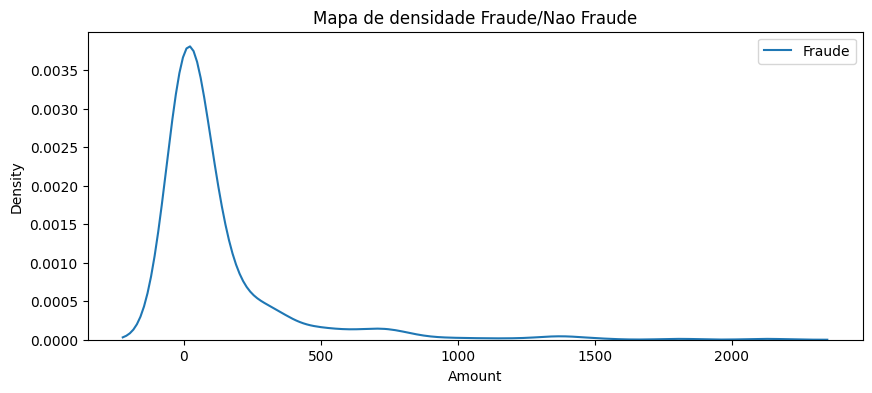

In [41]:
# Analisando os valores dos casos de fraude
df_valor_fraude = df.loc[df['Class'] == 1]['Amount']

fig, ax = plt.subplots(figsize=(10, 4))

sns.kdeplot(df_valor_fraude, label='Fraude')

ax.set_title('Mapa de densidade Fraude/Nao Fraude')
ax.legend()
plt.show()

In [42]:
df.loc[df['Class'] == 1]['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [43]:
# Temos casos zerados?
df.loc[(df['Class'] == 1) & (df['Amount'] == 0)].shape

(27, 31)

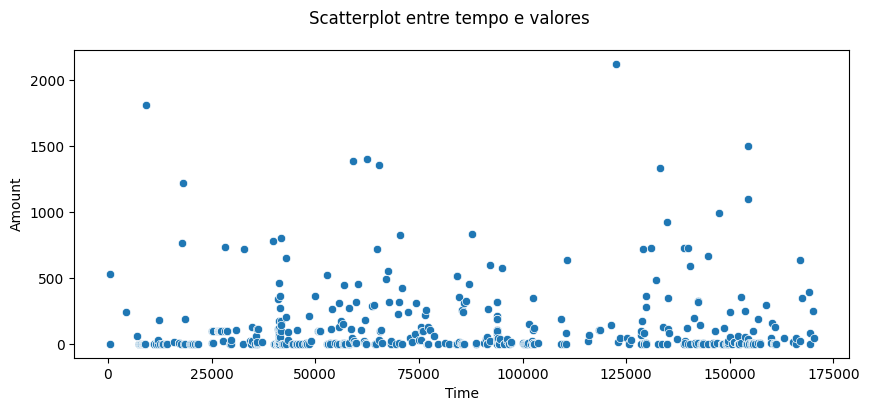

In [44]:
df_fraude = df.loc[df['Class'] == 1]

fig, axis = plt.subplots(figsize=(10, 4))
sns.scatterplot(data=df_fraude, x='Time', y='Amount')
fig.suptitle('Scatterplot entre tempo e valores')
plt.show()

## Split

In [45]:
# Primeiro vamos pegar 20% para teste
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class', 'Time'])
y = df['Class']
print(X.shape)
print(y.shape)

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

(284807, 29)
(284807,)


In [46]:
# Para os 80% que sobraram, vamos dividir em treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [47]:
# Organizando os indexes
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [48]:
# Como está a variável resposta?
print("Fraudes treino:", y_train.sum())
print("Fraudes validação:", y_val.sum())
print("Fraudes teste:", y_test.sum())

Fraudes treino: 295
Fraudes validação: 99
Fraudes teste: 98


In [49]:
# 20% para teste, 20% para validação e 60% para treino
print(X_test.shape)
print(X_train.shape)
print(X_val.shape)

(56962, 29)
(170883, 29)
(56962, 29)


## Treino

In [50]:
# Qual é a proporção das classes?
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(578.264406779661)

In [51]:
# Parâmetros do modelo
params = {
    #"scale_pos_weight": 550, não melhorou!
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 50,
    "min_sum_hessian_in_leaf": 1e-3,
    "feature_pre_filter": False,
    "verbosity": -1,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "feature_fraction": 0.8,
    "seed": 42,
    "feature_fraction_seed": 42,
    "bagging_seed": 42,
}

In [52]:
# Treinando o modelo
evals_results = {}

model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.record_evaluation(evals_results),
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 1	train's average_precision: 1	valid's auc: 0.958754	valid's average_precision: 0.770155
Early stopping, best iteration is:
[64]	train's auc: 1	train's average_precision: 0.999966	valid's auc: 0.960488	valid's average_precision: 0.761774


## Métricas

In [53]:
# Encontrando o melhor threshold
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.001, 0.01, 0.001)

melhor_threshold = 0.001
melhor_f1 = -1

y_val_proba = model.predict(X_val)

for th in thresholds:
    y_val_pred = (y_val_proba >= th).astype(int)
    f1 = f1_score(y_val, y_val_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = th

print("Melhor threshold:", melhor_threshold)
print("Melhor F1 validação:", melhor_f1)

Melhor threshold: 0.009000000000000001
Melhor F1 validação: 0.6582278481012658


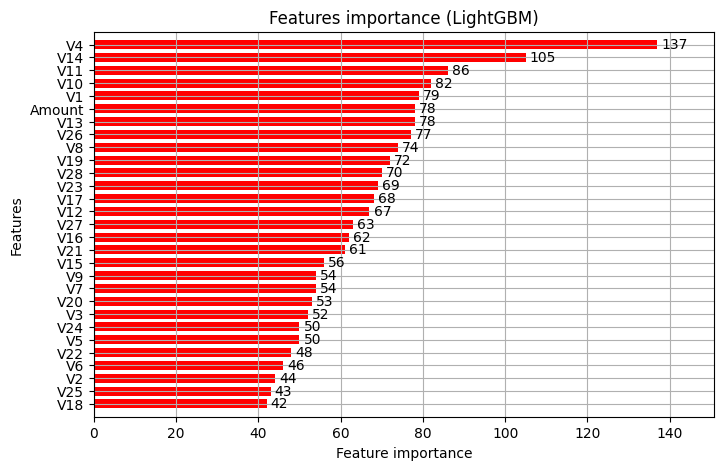

In [54]:
# Importância das Features
fig, ax = plt.subplots(ncols=1, figsize=(8, 5))
lgb.plot_importance(model, height=0.7, title="Features importance (LightGBM)", ax=ax,color="red") 
plt.show()

Average Precision: 0.7618


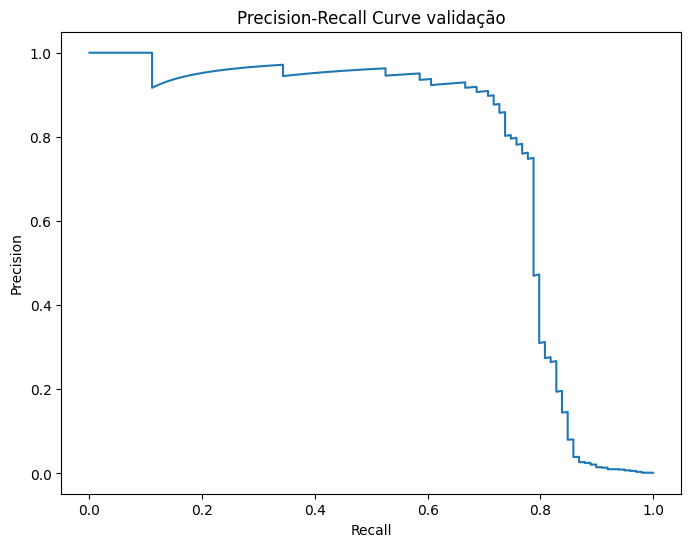

In [55]:
# Curva Precision-Recall considerando a base de vaidação
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
ap = average_precision_score(y_val, y_val_proba)
print(f"Average Precision: {ap:.4f}")

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve validação')

plt.show()


Matriz de Confusão:
[[56779    85]
 [   14    84]]


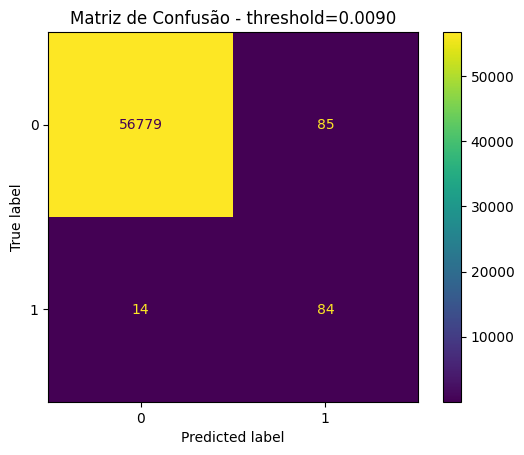


Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9985    0.9991     56864
           1     0.4970    0.8571    0.6292        98

    accuracy                         0.9983     56962
   macro avg     0.7484    0.9278    0.8142     56962
weighted avg     0.9989    0.9983    0.9985     56962



In [56]:
# Matriz de confusão considerando a base de teste
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Previsões (probabilidade)
y_test_proba = model.predict(X_test)

# Definir threshold
threshold = melhor_threshold 

y_pred = (y_test_proba >= threshold).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusão:")
print(cm)

# Plot da matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de Confusão - threshold={threshold:.4f}")
plt.show()

# Métricas detalhadas
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

In [57]:
top_k = int(0.01 * len(y_test_proba))  # top 1%

idx = np.argsort(y_test_proba)[-top_k:]

recall_top_k = y_test.iloc[idx].sum() / y_test.sum()

print(f"Top 1% das transações: {top_k}")
print(f"Recall no top 1%: {recall_top_k:.4f}")

Top 1% das transações: 569
Recall no top 1%: 0.8878


AUC: 0.9728


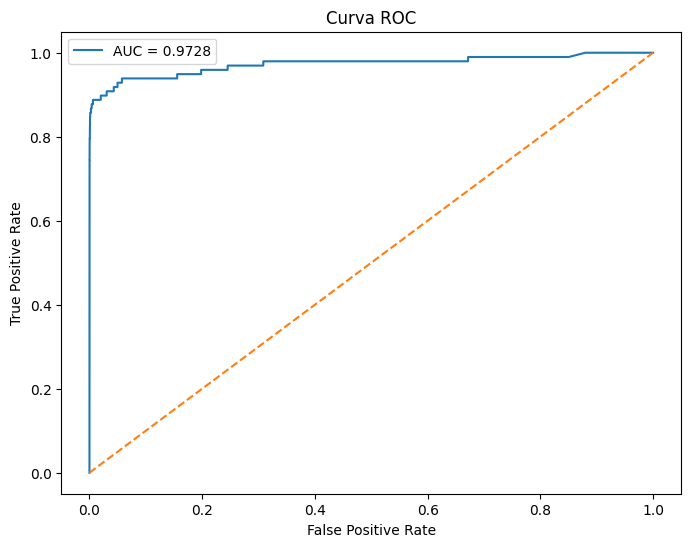

In [58]:
# Curva ROC considerando a base de teste
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Previsões (probabilidades)
y_pred = model.predict(X_test)

# Métricas ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
ax.plot([0,1], [0,1], linestyle='--')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC')
ax.legend()
plt.show()

In [59]:
frauds_top_k = y_test.iloc[idx].sum()
precision_top_k = frauds_top_k / top_k
precision_top_k

np.float64(0.15289982425307558)

## Exportando artefatos

In [60]:
# Salvando o artefato do modelo
import joblib
joblib.dump(model, '../artifacts/modelo_lbm.pkl')


['../artifacts/modelo_lbm.pkl']

In [88]:
# Salvando as colunas do modelo e o threshold
print(X_test.columns)
joblib.dump(X_test.columns.tolist(), '../artifacts/colunas_modelo.pkl')

print(threshold)
joblib.dump(threshold, '../artifacts/threshold.pkl')

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')
0.009000000000000001


['../artifacts/threshold.pkl']

## Testando um caso

In [ ]:
model = joblib.load('../artifacts/modelo_lbm.pkl')
threshold = joblib.load('../artifacts/threshold.pkl')
print(X_train.shape)
print(y_train.shape)

# Pegando um caso para tentar reperformar
result_teste = model.predict(X_test.iloc[0])[0]
print(result_teste)
print(y_pred[0])
print(f'O threshold eh: {threshold}')
classe_predita = 'fraude' if result_teste >= threshold else 'nao_fraude'
print(classe_predita)

(170883, 29)
(170883,)
7.353266943903357e-05
7.353266943903357e-05
 O threshold eh: 0.009000000000000001
nao_fraude
